In [254]:
# Importing packages
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc, average_precision_score
import matplotlib.pyplot as plt

In [255]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [256]:
# Reading and printing the dataset
data = pd.read_csv('/content/drive/MyDrive/MATH 6912 Group Project/data.csv')
# 1 = Not Bankrupt, 0 = Bankrupt
print(data.head(5))

   Bankrupt?   ROA(C) before interest and depreciation before interest  \
0          1                                           0.370594          
1          1                                           0.464291          
2          1                                           0.426071          
3          1                                           0.399844          
4          1                                           0.465022          

    ROA(A) before interest and % after tax  \
0                                 0.424389   
1                                 0.538214   
2                                 0.499019   
3                                 0.451265   
4                                 0.538432   

    ROA(B) before interest and depreciation after tax  \
0                                           0.405750    
1                                           0.516730    
2                                           0.472295    
3                                           0.4577

In [257]:
# Defining features and targets
X = data.drop(columns=['Bankrupt?'])
y = data['Bankrupt?']

In [258]:
# Scaling dataset using Standard Scaler
X_scaled = StandardScaler().fit_transform(X)

In [259]:
# Using PCA to reduce the dimensionality and find the number of features with 90% and 95% variance
from sklearn.decomposition import PCA

pca_90 = PCA(n_components=0.90)
X_pca_90 = pca_90.fit_transform(X_scaled)
print(pca_90.n_components_)

pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(X_scaled)
print(pca_95.n_components_)

45
53


In [260]:
# Calculating mutual information
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_scaled, y)
mi_scores = pd.Series(mi_selector.scores_, index=X.columns).dropna().sort_values(ascending=False)

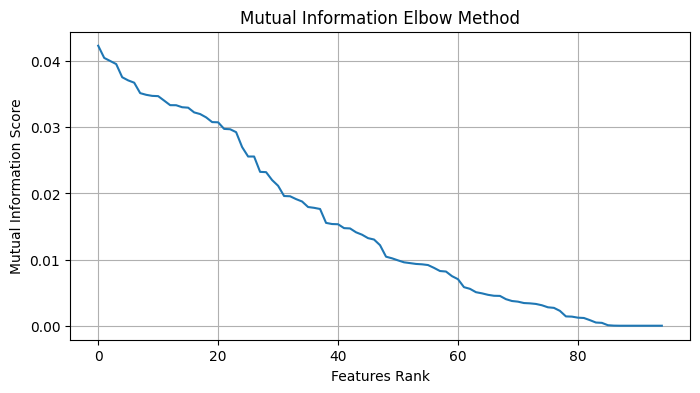

In [261]:
# Plotting mutual information with different numbers of feature to find elbow
plt.figure(figsize=(8, 4))
mi_scores.reset_index(drop=True).plot()
plt.title("Mutual Information Elbow Method")
plt.xlabel("Features Rank")
plt.ylabel("Mutual Information Score")
plt.grid(True)
plt.show()

In [262]:
# Showing the most important features and their mutual information score
for n in [5, 10, 13, 20, 45, 53]:
    print(f"\n Top {n} features that were identified by mutual information:")
    top_n = mi_scores.head(n)
    for feature, score in top_n.items():
        print(f"{feature}: {score:.4f}")


 Top 5 features that were identified by mutual information:
 Persistent EPS in the Last Four Seasons: 0.0423
 Net Income to Stockholder's Equity: 0.0405
 Borrowing dependency: 0.0400
 Net profit before tax/Paid-in capital: 0.0396
 Per Share Net profit before tax (Yuan ¥): 0.0376

 Top 10 features that were identified by mutual information:
 Persistent EPS in the Last Four Seasons: 0.0423
 Net Income to Stockholder's Equity: 0.0405
 Borrowing dependency: 0.0400
 Net profit before tax/Paid-in capital: 0.0396
 Per Share Net profit before tax (Yuan ¥): 0.0376
 ROA(A) before interest and % after tax: 0.0371
 Net Income to Total Assets: 0.0367
 Continuous interest rate (after tax): 0.0352
 Interest Expense Ratio: 0.0349
 Net worth/Assets: 0.0347

 Top 13 features that were identified by mutual information:
 Persistent EPS in the Last Four Seasons: 0.0423
 Net Income to Stockholder's Equity: 0.0405
 Borrowing dependency: 0.0400
 Net profit before tax/Paid-in capital: 0.0396
 Per Share Net pr

In [263]:
# Creating a top features sets and store the storing results
results = []
top_n_list = [5, 10, 13, 20, 45, 53]

KNN Model with Top 5 features:
The best K is 1
              precision    recall  f1-score   support

           0     0.9808    0.9311    0.9553      1320
           1     0.1802    0.4545    0.2581        44

    accuracy                         0.9157      1364
   macro avg     0.5805    0.6928    0.6067      1364
weighted avg     0.9550    0.9157    0.9328      1364



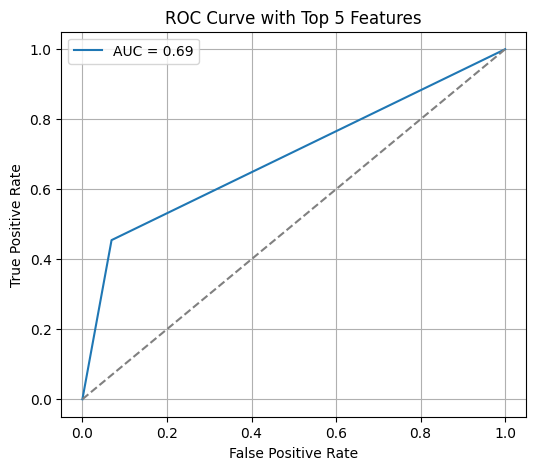

KNN Model with Top 10 features:
The best K is 1
              precision    recall  f1-score   support

           0     0.9801    0.9326    0.9557      1320
           1     0.1759    0.4318    0.2500        44

    accuracy                         0.9164      1364
   macro avg     0.5780    0.6822    0.6029      1364
weighted avg     0.9542    0.9164    0.9330      1364



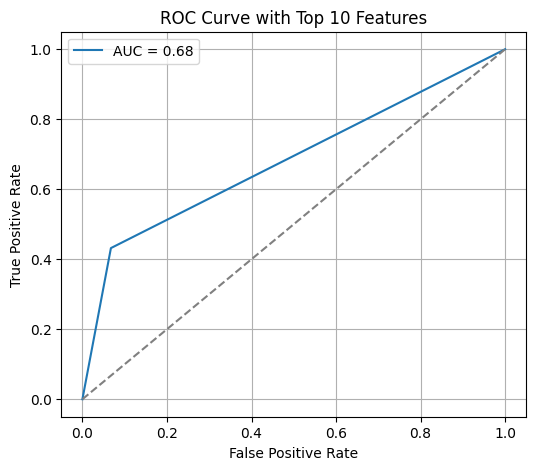

KNN Model with Top 13 features:
The best K is 1
              precision    recall  f1-score   support

           0     0.9826    0.9409    0.9613      1320
           1     0.2200    0.5000    0.3056        44

    accuracy                         0.9267      1364
   macro avg     0.6013    0.7205    0.6334      1364
weighted avg     0.9580    0.9267    0.9401      1364



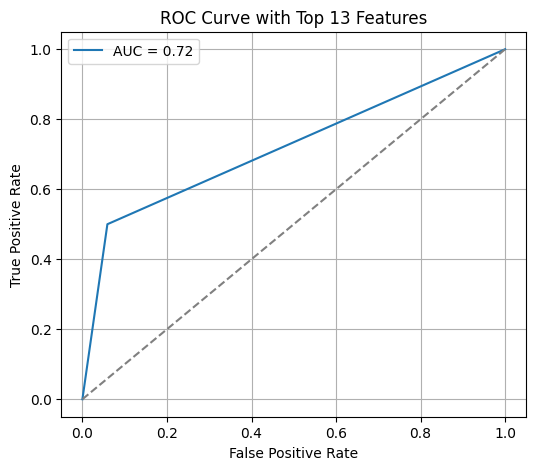

KNN Model with Top 20 features:
The best K is 1
              precision    recall  f1-score   support

           0     0.9818    0.9394    0.9601      1320
           1     0.2079    0.4773    0.2897        44

    accuracy                         0.9245      1364
   macro avg     0.5949    0.7083    0.6249      1364
weighted avg     0.9568    0.9245    0.9385      1364



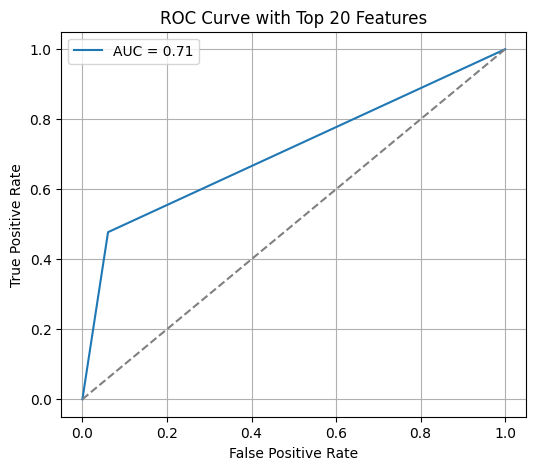

KNN Model with Top 45 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9835    0.9500    0.9665      1320
           1     0.2584    0.5227    0.3459        44

    accuracy                         0.9362      1364
   macro avg     0.6210    0.7364    0.6562      1364
weighted avg     0.9601    0.9362    0.9465      1364



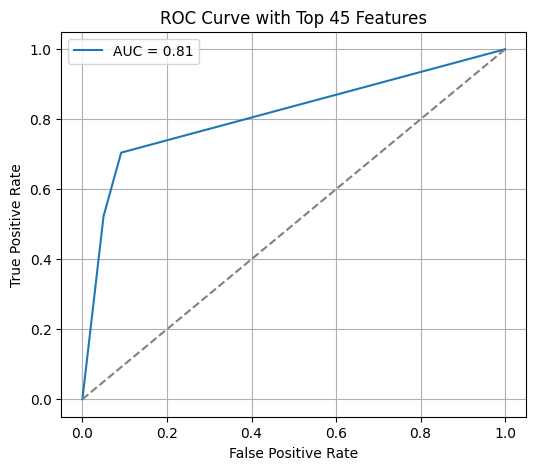

KNN Model with Top 53 features:
The best K is 2
              precision    recall  f1-score   support

           0     0.9828    0.9530    0.9677      1320
           1     0.2619    0.5000    0.3438        44

    accuracy                         0.9384      1364
   macro avg     0.6224    0.7265    0.6557      1364
weighted avg     0.9596    0.9384    0.9476      1364



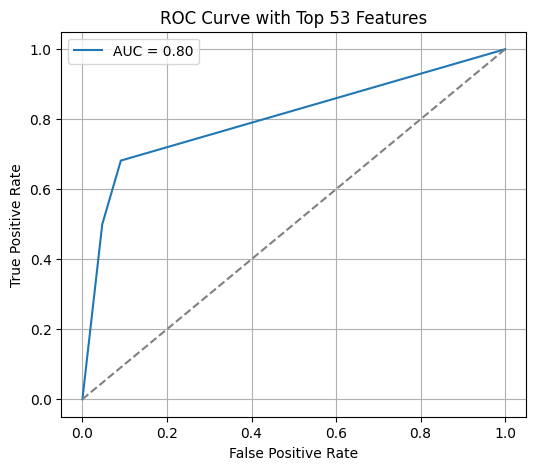

In [264]:
# Setting up for loop to show each features
for n in top_n_list:
    print(f"KNN Model with Top {n} features:")

    # Selecting each top feature
    selected_features = mi_scores.head(n).index.tolist()

    # Obtaining features
    X_sel = X[selected_features]

    # Slicing dataset to 60% training set, 20% validation set, and 20% test set
    X_temp, X_test, y_temp, y_test = train_test_split(X_sel, y, test_size=0.2, stratify=y, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

    # Scaling dataset for KNN model
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_val_std = scaler.transform(X_val)
    X_test_std = scaler.transform(X_test)

    # Fitting training set to smote to balance the data
    sm = SMOTE(random_state=42)
    X_train_bal, y_train_bal = sm.fit_resample(X_train_std, y_train)

    # Checking the best K using cross validation
    best_k = 1
    best_f1 = 0
    for k_try in range(1, 21):
        knn_try = KNeighborsClassifier(n_neighbors=k_try)
        f1 = cross_val_score(knn_try, X_train_bal, y_train_bal, cv=5, scoring='f1').mean()
        if f1 > best_f1:
            best_k = k_try
            best_f1 = f1

    print(f"The best K is {best_k}")

    # Fitting balanced dataset to KNN classifier
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train_bal, y_train_bal)

    # Using the test set and calculauting AUC
    y_pred = knn.predict(X_test_std)
    y_proba = knn.predict_proba(X_test_std)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    print(classification_report(y_test, y_pred, digits=4))

    # Plotting ROC AUC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve with Top {n} Features")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Storing all results
    results.append({
        "Top K Features": k,
        "Best K": best_k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc
    })